Retrieved 753 trading days (2023-06-06 to 2026-06-05).

Train samples: 594 | Test samples: 149

Linear Regression
  MAE : 2.671
  RMSE: 3.667
  R^2 : 0.9481

Random Forest
  MAE : 8.579
  RMSE: 14.159
  R^2 : 0.2268

Best model by RMSE: Linear Regression

Saved: AAPL_actual_vs_predicted.png


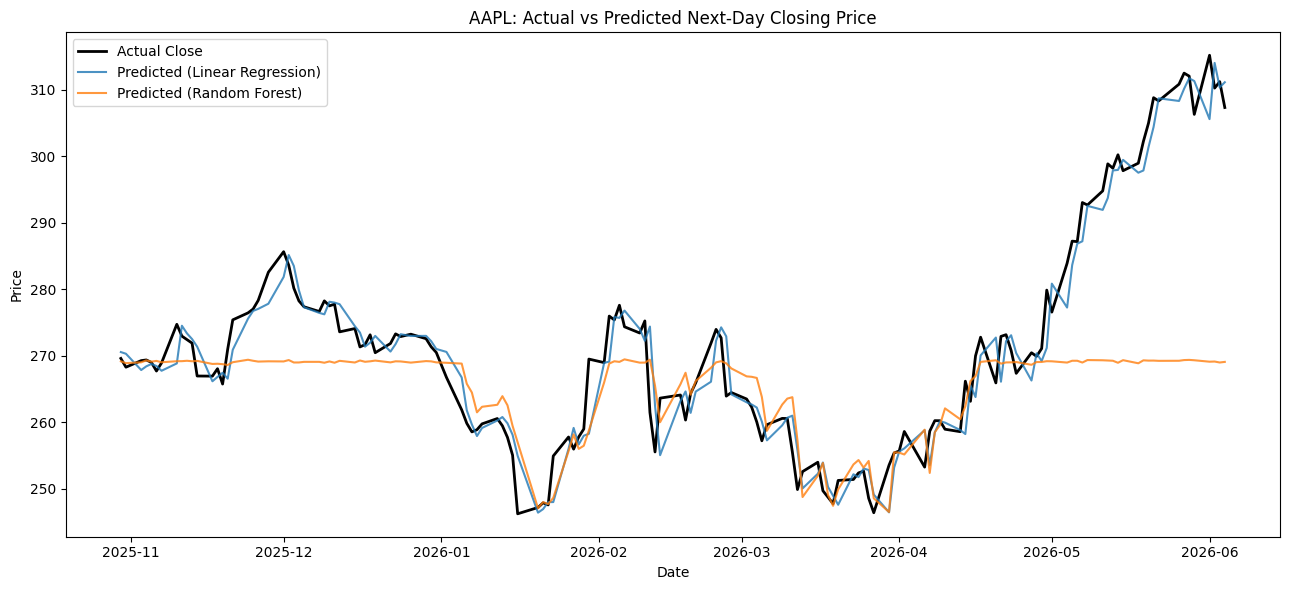

Saved: AAPL_feature_importance.png


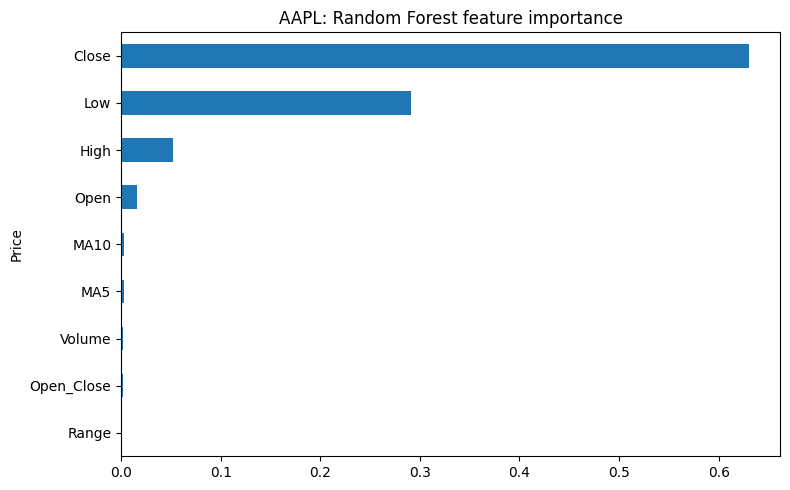

In [1]:
import argparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def load_stock(ticker, period):
    """Download historical data and return a clean DataFrame."""
    print(f"Downloading {ticker} data (period={period}) ...")
    df = yf.download(ticker, period=period, auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError(
            f"No data returned for '{ticker}'. Check the symbol / connection."
        )
    # yfinance may return a MultiIndex column for a single ticker; flatten it.
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
    print(f"Retrieved {len(df)} trading days "
          f"({df.index.min().date()} to {df.index.max().date()}).")
    return df


def build_features(df):
    """Create the feature matrix X and target y (next day's Close)."""
    data = df.copy()

    # A few simple engineered features often help short-term prediction.
    data["Range"] = data["High"] - data["Low"]
    data["Open_Close"] = data["Close"] - data["Open"]
    data["MA5"] = data["Close"].rolling(5).mean()
    data["MA10"] = data["Close"].rolling(10).mean()

    # Target: tomorrow's closing price.
    data["Target"] = data["Close"].shift(-1)

    data = data.dropna()

    feature_cols = [
        "Open", "High", "Low", "Close", "Volume",
        "Range", "Open_Close", "MA5", "MA10",
    ]
    X = data[feature_cols]
    y = data["Target"]
    return X, y, data.index


def evaluate(name, y_true, y_pred):
    """Print regression metrics for a model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print(f"  MAE : {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R^2 : {r2:.4f}")
    return {"name": name, "mae": mae, "rmse": rmse, "r2": r2}


def main():
    parser = argparse.ArgumentParser(description="Short-term stock price prediction")
    parser.add_argument("--ticker", default="AAPL", help="Stock symbol (e.g. AAPL, TSLA)")
    parser.add_argument("--period", default="3y", help="History window (e.g. 1y, 3y, 5y, max)")
    parser.add_argument("--test-size", type=float, default=0.2,
                        help="Fraction of most-recent data used for testing")
    args, unknown = parser.parse_known_args() # Modified line

    df = load_stock(args.ticker, args.period)
    X, y, dates = build_features(df)

    # Time-based split: train on the past, test on the most recent slice.
    split = int(len(X) * (1 - args.test_size))
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]
    test_dates = dates[split:]
    print(f"\nTrain samples: {len(X_train)} | Test samples: {len(X_test)}")

    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, random_state=42, n_jobs=-1
        ),
    }

    results = {}
    predictions = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        predictions[name] = pred
        results[name] = evaluate(name, y_test, pred)

    best = min(results.values(), key=lambda r: r["rmse"])["name"]
    print(f"\nBest model by RMSE: {best}")

    # Plot actual vs predicted closing prices on the test period -------------
    plt.figure(figsize=(13, 6))
    plt.plot(test_dates, y_test.values, label="Actual Close", color="black", linewidth=2)
    for name, pred in predictions.items():
        plt.plot(test_dates, pred, label=f"Predicted ({name})", alpha=0.8)
    plt.title(f"{args.ticker}: Actual vs Predicted Next-Day Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    out = f"{args.ticker}_actual_vs_predicted.png"
    plt.savefig(out, dpi=120)
    print(f"\nSaved: {out}")
    plt.show()

    # Random Forest feature importances (handy for interpretation) -----------
    rf = models["Random Forest"]
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
    plt.figure(figsize=(8, 5))
    importances.plot(kind="barh")
    plt.title(f"{args.ticker}: Random Forest feature importance")
    plt.tight_layout()
    plt.savefig(f"{args.ticker}_feature_importance.png", dpi=120)
    print(f"Saved: {args.ticker}_feature_importance.png")
    plt.show()


if __name__ == "__main__":
    main()